In [2]:
import numpy as np

from matplotlib.markers import MarkerStyle
from matplotlib.lines import Line2D

import superconductivity.api as sc

from superconductivity.api import G0_muS
from superconductivity.api import NDArray64

from IPython import get_ipython

_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("reload_ext", "autoreload")
    _ip.run_line_magic("autoreload", "2")

    _ip.run_line_magic(
        "config",
        "InlineBackend.print_figure_kwargs = {'bbox_inches': None, 'pad_inches': 0.0}",
    )
    _ip.run_line_magic("config", 'InlineBackend.figure_format = "retina"')  # or "png"
    _ip.run_line_magic(
        "config", "InlineBackend.rc = {'figure.dpi': 300}"
    )  # choose a value you like

np.float64(45.286842105263155)

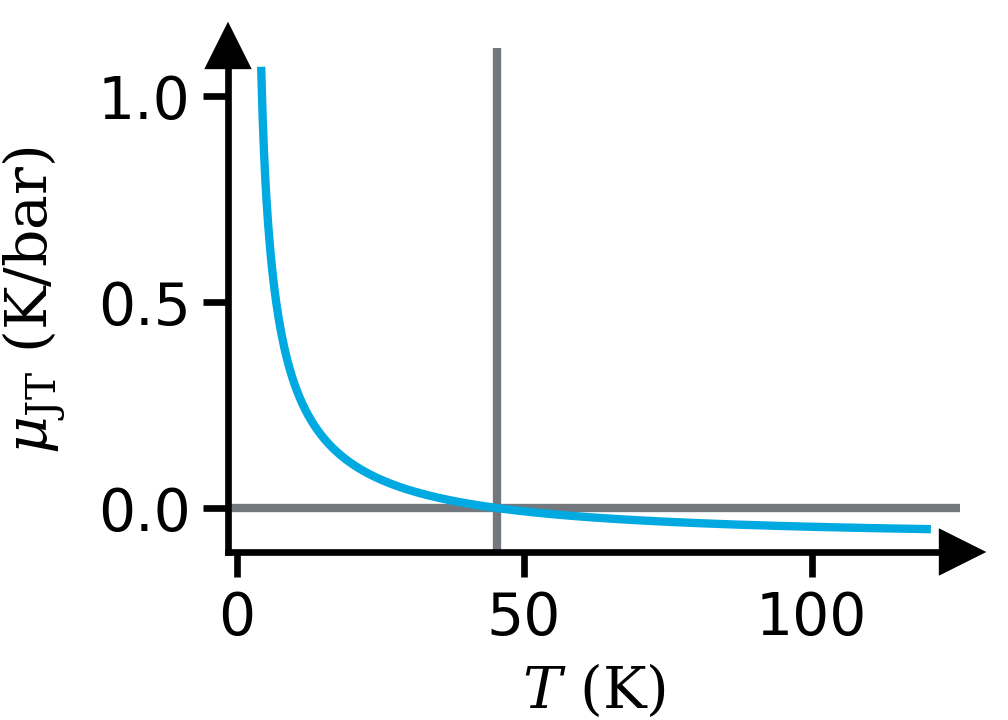

In [3]:
import CoolProp.CoolProp as CP

T = np.linspace(4.3, 120, 495)  # K
pressures_bar = [1, 5, 10, 20, 50]
pressures_bar = [1]

figsize = (1.68, 1.2)
fig, ax = sc.get_figure(figsize=figsize, padding=(0.3, 0.2))

ax.axhline(0, lw=1, color=sc.seegrau100)
for p_bar in pressures_bar:
    p = p_bar * 1e5  # bar -> Pa
    mu = np.array([CP.PropsSI("d(T)/d(P)|H", "T", Ti, "P", p, "Helium") for Ti in T])
    T0 = T[np.argmin(np.abs(mu))]
    ax.axvline(T0, color=sc.seegrau100)
    ax.plot(T, mu * 1e5, label=f"{p_bar} bar", color=sc.seeblau100)  # K/Pa -> K/bar

# plt.xlabel("T (K)")
# plt.ylabel(r"$\mu_\mathrm{JT}$ (K/bar)")
# # plt.legend()
# plt.show()

xlabel = "$T\\ \\mathrm{(K)}$"
ylabel = "$\\mu_\\mathrm{JT}\\ \\mathrm{(K/bar)}$"
title = "methods/setup/cryo/joule-thomson"

sc.theory_layout(fig, ax, title, xlabel, ylabel)
T0

In [4]:
# phase diagram data
dilution = np.array(
    [
        [0.06285714285714317, 0],
        [0.06857142857142895, 0.06878980891719744],
        [0.0771428571428574, 0.1375796178343951],
        [0.10571428571428587, 0.24649681528662426],
        [0.14285714285714324, 0.3496815286624204],
        [0.18000000000000016, 0.4242038216560511],
        [0.20857142857142885, 0.47579617834394905],
        [0.245714285714286, 0.5331210191082802],
        [0.27714285714285747, 0.5789808917197452],
        [0.30857142857142883, 0.6191082802547772],
        [0.3371428571428574, 0.6477707006369429],
        [0.37714285714285745, 0.6878980891719746],
        [0.41714285714285737, 0.7222929936305733],
        [0.4571428571428574, 0.7509554140127388],
        [0.5085714285714288, 0.7910828025477707],
        [0.5485714285714288, 0.8140127388535032],
        [0.5971428571428575, 0.8426751592356687],
        [0.6428571428571431, 0.8598726114649682],
        [0.6714285714285717, 0.8713375796178344],
    ]
)

separation = np.array(
    [
        [1, 0.1433121019108281],
        [0.9942857142857144, 0.1949044585987263],
        [0.9885714285714288, 0.23503184713375802],
        [0.9771428571428574, 0.3],
        [0.9714285714285718, 0.32675159235668794],
        [0.9542857142857146, 0.3783439490445861],
        [0.9371428571428574, 0.41847133757961785],
        [0.9200000000000004, 0.4585987261146498],
        [0.8971428571428572, 0.5044585987261145],
        [0.8771428571428574, 0.5388535031847135],
        [0.8542857142857145, 0.5789808917197452],
        [0.8342857142857146, 0.6191082802547772],
        [0.8171428571428574, 0.6420382165605096],
        [0.7971428571428574, 0.6764331210191084],
        [0.782857142857143, 0.6993630573248408],
        [0.7714285714285718, 0.7222929936305733],
        [0.7571428571428573, 0.7394904458598728],
        [0.7457142857142861, 0.756687898089172],
        [0.7342857142857145, 0.7796178343949045],
        [0.7171428571428575, 0.802547770700637],
        [0.7028571428571431, 0.8197452229299365],
        [0.6828571428571432, 0.8541401273885352],
        [0.6714285714285717, 0.8713375796178344],
    ]
)

lambda_line = np.array(
    [
        [0.23686507936507972, 1.7985403397027602],
        [0.250092592592593, 1.778635881104034],
        [0.26166666666666705, 1.758731422505308],
        [0.2732407407407411, 1.742144373673036],
        [0.28646825396825437, 1.72223991507431],
        [0.3013492063492068, 1.6923832271762207],
        [0.3112698412698417, 1.675796178343949],
        [0.32615079365079414, 1.6492569002123143],
        [0.3393783068783074, 1.6260350318471337],
        [0.3542592592592597, 1.599495753715499],
        [0.37079365079365123, 1.5663216560509554],
        [0.39559523809523855, 1.5165605095541401],
        [0.4071693121693126, 1.4933386411889595],
        [0.42205026455026495, 1.460164543524416],
        [0.4352777777777782, 1.4336252653927812],
        [0.45181216931216983, 1.3971337579617833],
        [0.47000000000000053, 1.3606422505307854],
        [0.4832275132275138, 1.330785562632696],
        [0.4964550264550269, 1.300928874734607],
        [0.5096825396825401, 1.2677547770700637],
        [0.5196031746031751, 1.244532908704883],
        [0.5344841269841274, 1.2080414012738854],
        [0.5460582010582015, 1.1781847133757961],
        [0.5642460317460323, 1.1350583864118895],
        [0.5791269841269847, 1.0985668789808916],
        [0.5989682539682545, 1.0488057324840763],
        [0.6155026455026461, 1.008996815286624],
        [0.6287301587301594, 0.9758227176220805],
        [0.6452645502645508, 0.9326963906581739],
        [0.6584920634920639, 0.8995222929936304],
        [0.6714285714285717, 0.8713375796178344],
    ]
)
brewer = np.array([[0.9991005291005297, 0.14315286624203782]])
edwards = np.array(
    [
        [0.08144179894179948, 0.1597399150743095],
        [0.09962962962962996, 0.2061836518046707],
        [0.11947089947089973, 0.285801486199575],
        [0.15088624338624368, 0.36541932059447957],
    ]
)
debuyn = np.array(
    [
        [0.28977513227513274, 1.7156050955414013],
        [0.3889814814814819, 1.5364649681528662],
        [0.47826719576719623, 1.3506900212314223],
        [0.572513227513228, 1.1483280254777068],
        [0.6386507936507942, 0.9526008492569],
        [0.6998280423280429, 0.8265392781316345],
        [0.7494312169312175, 0.7568736730360932],
        [0.8039947089947097, 0.6673036093418256],
        [0.8469841269841275, 0.5976380042462841],
        [0.8932804232804238, 0.4981157112526535],
        [0.9544576719576725, 0.3786889596602969],
        [0.6386507936507942, 0.8696656050955414],
        [0.572513227513228, 0.8398089171974521],
        [0.47661375661375716, 0.7701433121019108],
        [0.38732804232804274, 0.6938428874734606],
        [0.2914285714285718, 0.5876857749469211],
        [0.1492328042328046, 0.3919585987261145],
    ]
)

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, to_rgba


def gradient_fill_between(
    ax,
    x,
    y1,
    y2=0,
    color_start="C0",
    color_end="C0",
    alpha_start=0.0,
    alpha_end=0.6,
    angle=0.0,
    resolution=512,
    zorder=None,
):
    """
    Gradient-fill the region between y1 and y2.

    angle = 0       : left to right
    angle = 90      : bottom to top
    angle = 180     : right to left
    angle = -90     : top to bottom
    """
    x = np.asarray(x)
    y1 = np.asarray(y1)

    if np.isscalar(y2):
        y2 = np.full_like(y1, y2, dtype=float)
    else:
        y2 = np.asarray(y2)

    polygon = ax.fill_between(x, y1, y2, facecolor="none", edgecolor="none")

    xmin, xmax = np.nanmin(x), np.nanmax(x)
    ymin = np.nanmin(np.r_[y1, y2])
    ymax = np.nanmax(np.r_[y1, y2])

    rgba_start = to_rgba(color_start, alpha_start)
    rgba_end = to_rgba(color_end, alpha_end)

    cmap = LinearSegmentedColormap.from_list(
        "angled_fill_between_gradient",
        [rgba_start, rgba_end],
    )

    xs = np.linspace(0, 1, resolution)
    ys = np.linspace(0, 1, resolution)
    xx, yy = np.meshgrid(xs, ys)

    theta = np.deg2rad(angle)
    gradient = xx * np.cos(theta) + yy * np.sin(theta)
    gradient -= gradient.min()
    gradient /= gradient.max()

    im = ax.imshow(
        gradient,
        extent=[xmin, xmax, ymin, ymax],
        origin="lower",
        aspect="auto",
        cmap=cmap,
        zorder=zorder,
    )

    im.set_clip_path(polygon.get_paths()[0], transform=ax.transData)

    return im

In [146]:
import numpy as np
from matplotlib.path import Path


def scatter_density_fill_polygon(
    ax,
    x,
    y,
    cutout_x=None,
    cutout_y=None,
    n_points=3000,
    density_start=0.05,
    density_end=1.0,
    angle=0.0,
    color="C0",
    edgecolor="black",
    linewidth=0.3,
    s=12,
    alpha=0.8,
    seed=None,
    zorder=None,
    max_iter=100,
):
    rng = np.random.default_rng(seed)

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if x.shape != y.shape:
        raise ValueError("x and y must have the same shape.")

    valid = np.isfinite(x) & np.isfinite(y)
    outer_vertices = np.column_stack([x[valid], y[valid]])

    if len(outer_vertices) < 3:
        raise ValueError("The outer polygon needs at least three valid vertices.")

    if not np.allclose(outer_vertices[0], outer_vertices[-1]):
        outer_vertices = np.vstack([outer_vertices, outer_vertices[0]])

    outer_path = Path(outer_vertices)

    cutout_x = [] if cutout_x is None else cutout_x
    cutout_y = [] if cutout_y is None else cutout_y

    if len(cutout_x) != len(cutout_y):
        raise ValueError("cutout_x and cutout_y must have the same number of entries.")

    cutout_paths = []

    for cx, cy in zip(cutout_x, cutout_y):
        cx = np.asarray(cx, dtype=float)
        cy = np.asarray(cy, dtype=float)

        if cx.shape != cy.shape:
            raise ValueError("Each cutout x/y pair must have the same shape.")

        valid = np.isfinite(cx) & np.isfinite(cy)
        hole_vertices = np.column_stack([cx[valid], cy[valid]])

        if len(hole_vertices) < 3:
            continue

        if not np.allclose(hole_vertices[0], hole_vertices[-1]):
            hole_vertices = np.vstack([hole_vertices, hole_vertices[0]])

        cutout_paths.append(Path(hole_vertices))

    xmin, ymin = outer_vertices.min(axis=0)
    xmax, ymax = outer_vertices.max(axis=0)

    if xmax == xmin or ymax == ymin:
        raise ValueError("Outer polygon has zero width or height.")

    theta = np.deg2rad(angle)
    accepted = []

    batch_size = max(2000, 4 * n_points)

    for _ in range(max_iter):
        xs = rng.uniform(xmin, xmax, batch_size)
        ys = rng.uniform(ymin, ymax, batch_size)
        candidates = np.column_stack([xs, ys])

        mask = outer_path.contains_points(candidates)

        for hole_path in cutout_paths:
            mask &= ~hole_path.contains_points(candidates)

        points = candidates[mask]

        if len(points) == 0:
            continue

        xn = (points[:, 0] - xmin) / (xmax - xmin)
        yn = (points[:, 1] - ymin) / (ymax - ymin)

        g = xn * np.cos(theta) + yn * np.sin(theta)
        g -= g.min()

        if g.max() > 0:
            g /= g.max()

        density = density_start + (density_end - density_start) * g
        density = np.clip(density, 0, None)

        probability = (
            density / density.max() if density.max() > 0 else np.zeros_like(density)
        )

        keep = rng.random(len(points)) < probability
        points = points[keep]

        if len(points) > 0:
            accepted.append(points)

        if sum(len(p) for p in accepted) >= n_points:
            break

    if len(accepted) == 0:
        return ax.scatter(
            [],
            [],
            s=s,
            facecolors=color,
            edgecolors=edgecolor,
            linewidths=linewidth,
            alpha=alpha,
            zorder=zorder,
        )

    points = np.vstack(accepted)

    if len(points) > n_points:
        idx = rng.choice(len(points), size=n_points, replace=False)
        points = points[idx]

    scatter = ax.scatter(
        points[:, 0],
        points[:, 1],
        s=s,
        facecolors=color,
        edgecolors=edgecolor,
        linewidths=linewidth,
        alpha=alpha,
        zorder=zorder,
    )

    return scatter

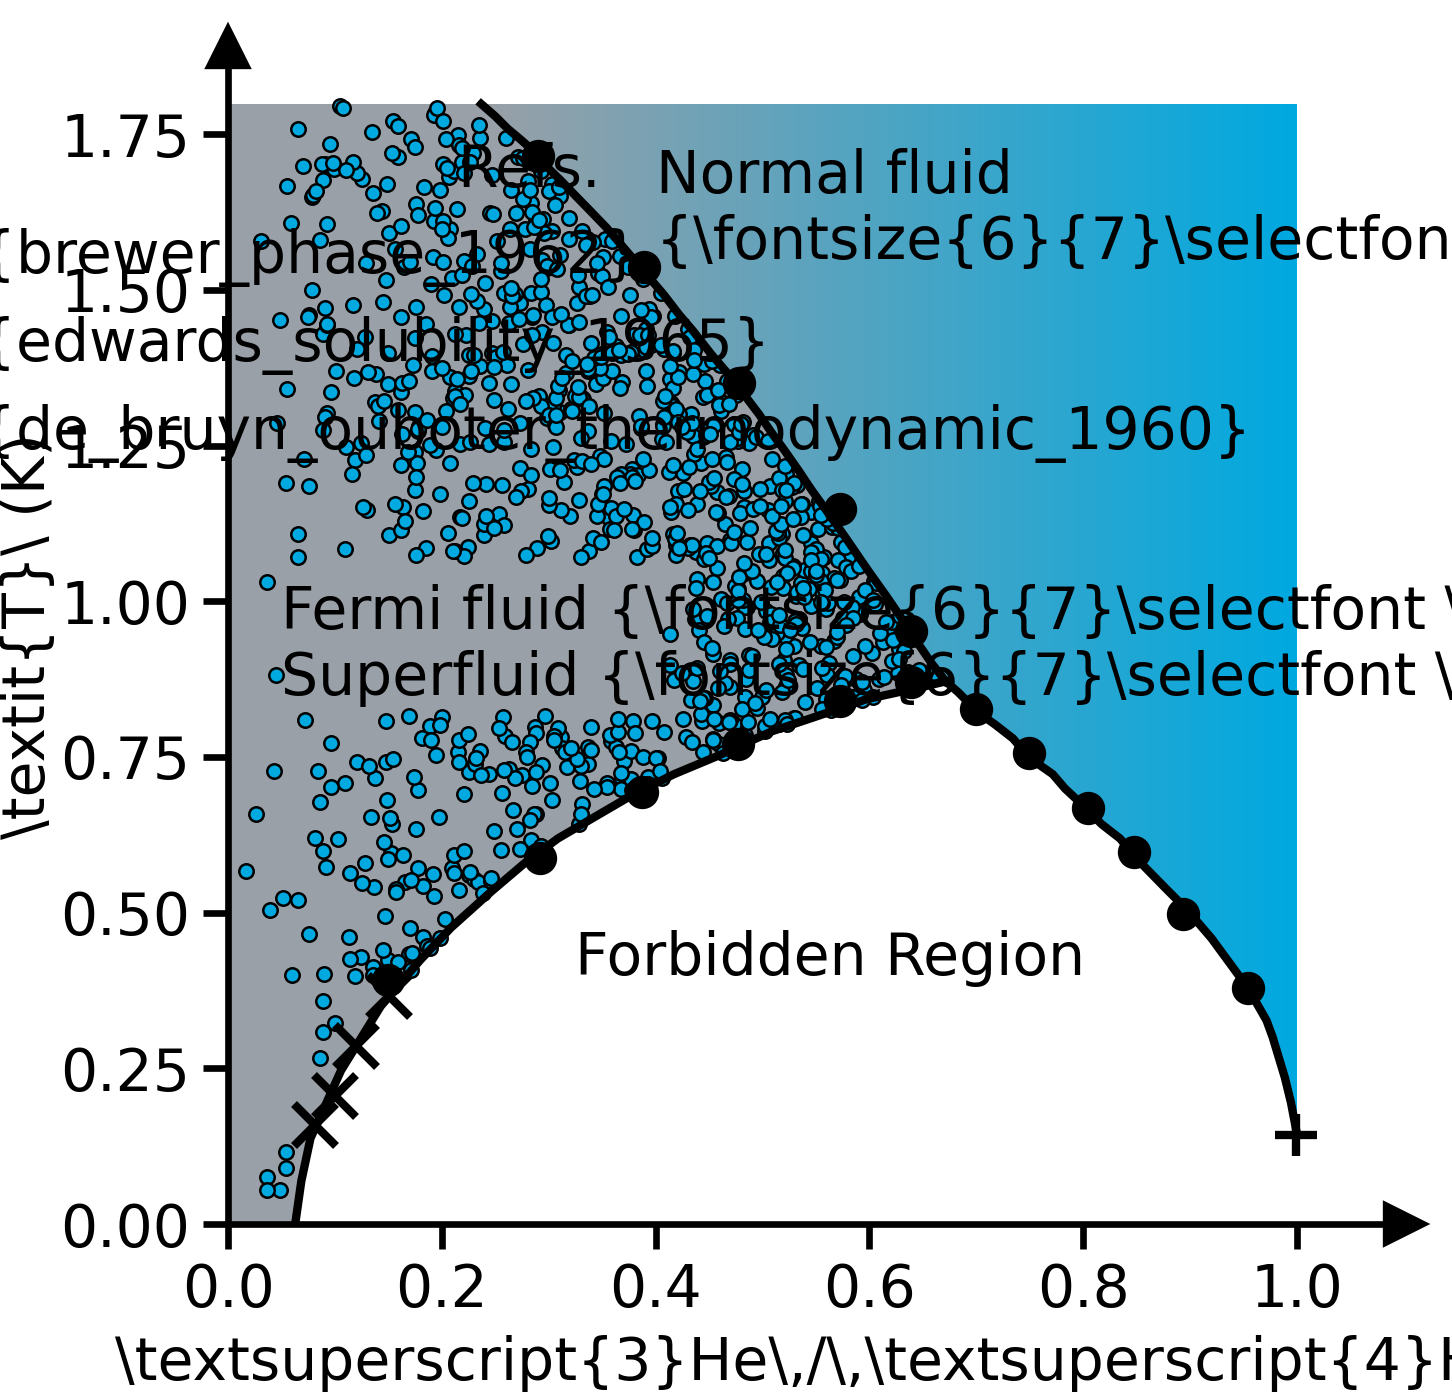

In [189]:
fig, ax = sc.get_figure(figsize=(2.42, 2.32), padding=(0.3, 0.2))

ax.plot(lambda_line[:, 0], lambda_line[:, 1], "-", color="k")
ax.plot(separation[:, 0], separation[:, 1], "-", color="k")
ax.plot(dilution[:, 0], dilution[:, 1], "-", color="k")

import matplotlib as mpl

mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "pgf.rcfonts": False,
        "pgf.preamble": r"""
\newcommand{\hethree}{\textsuperscript{3}He}
\newcommand{\hefour}{\textsuperscript{4}He}
""",
    }
)

ax.plot(
    brewer[:, 0],
    brewer[:, 1],
    "+",
    ms=5,
    color="k",
    label="\\cite{brewer_phase_1962}",
)
ax.plot(
    edwards[:, 0],
    edwards[:, 1],
    "x",
    ms=5,
    color="k",
    label="\\cite{edwards_solubility_1965}",
)
ax.plot(
    debuyn[:, 0],
    debuyn[:, 1],
    "o",
    ms=3,
    color="k",
    label="\\cite{de_bruyn_ouboter_thermodynamic_1960}",
)
ymin, ymax = ax.get_ylim()

# gradient_fill_between(
#     ax,
#     x=np.concatenate((np.zeros(1), dilution[:, 0], np.flip(separation[:, 0]))),
#     y1=np.concatenate((np.zeros(1), dilution[:, 1], np.flip(separation[:, 1]))),
#     y2=ymax,
#     color_start=sc.seegrau100,
#     color_end=sc.seeblau100,
#     alpha_end=1.0,
#     alpha_start=1.0,
# )
x = np.concatenate((np.array([0, 0]), dilution[:, 0], np.flip(lambda_line[:, 0])))
y = np.concatenate(
    (np.array([lambda_line[0, 1], 0]), dilution[:, 1], np.flip(lambda_line[:, 1]))
)
cutout_x = np.array([0.05, 0.41, 0.41, 0.43, 0.43, 0.05])
cutout_y = np.array([0.82, 0.82, 0.95, 0.95, 1.07, 1.07])
ax.fill_between(np.r_[x, x[0]], np.r_[y, y[0]], facecolor=sc.seegrau65, zorder=0)
# ax.plot(
#     np.r_[cutout_x, cutout_x[0]],
#     np.r_[cutout_y, cutout_y[0]],
#     color="C0",
# )
scatter_density_fill_polygon(
    ax=ax,
    x=x,
    y=y,
    cutout_x=[cutout_x],
    cutout_y=[cutout_y],
    n_points=1_000,
    density_start=0.0,
    density_end=dilution[-1, 0],
    angle=0,
    color=sc.seeblau100,
    s=3,
    alpha=1.0,
    seed=1,
)

gradient_fill_between(
    ax,
    x=np.concatenate((np.array([1, 1]), lambda_line[:, 0], np.flip(separation[:, 0]))),
    y1=np.concatenate(
        (np.array([0, lambda_line[0, 1]]), lambda_line[:, 1], np.flip(separation[:, 1]))
    ),
    y2=ymax,
    color_start=sc.seegrau65,
    color_end=sc.seeblau100,
    alpha_end=1.0,
    alpha_start=1.0,
)
# x = np.concatenate((np.array([1, 1]), lambda_line[:, 0], np.flip(separation[:, 0])))
# y = np.concatenate(
#     (np.array([0, lambda_line[0, 1]]), lambda_line[:, 1], np.flip(separation[:, 1]))
# )
# ax.fill_between(np.r_[x, x[0]], np.r_[y, y[0]], facecolor=sc.seeblau80, zorder=0)
# scatter_density_fill_polygon(
#     ax=ax,
#     x=x,
#     y=y,
#     cutout_x=[cutout_x],
#     cutout_y=[cutout_y],
#     n_points=1_500,
#     density_start=1 - lambda_line[0, 0],
#     density_end=0.0,
#     angle=0,
#     color=sc.seegrau100,
#     s=3,
#     alpha=1.0,
#     seed=1,
# )

# ax.set_ylim(0, 1.95)
ax.set_xlim(0, 1.1)
ax.legend(
    title="Refs.",
    handlelength=0.0,
    loc="upper right",
    bbox_to_anchor=(0.9, 0.95),
    frameon=False,
    fontsize=7,
    title_fontsize=7,
    ncols=1,
    columnspacing=0.3,
    borderpad=0.1,  # reduces padding inside the legend box
)

ax.annotate(
    "Normal fluid"
    + "\n"
    + r"{\fontsize{6}{7}\selectfont \textsuperscript{3}He}"
    + r"\,/\,"
    + r"{\fontsize{6}{7}\selectfont \textsuperscript{4}He}",
    xy=(0.4, 1.55),
    fontsize=7,
)

ax.annotate(
    "Fermi fluid "
    + r"{\fontsize{6}{7}\selectfont \textsuperscript{3}He}"
    + "\n"
    + "Superfluid "
    + r"{\fontsize{6}{7}\selectfont \textsuperscript{4}He}",
    xy=(0.05, 0.85),
    fontsize=7,
)

ax.annotate(
    "Forbidden Region",
    xy=(0.325, 0.4),
    fontsize=7,
)

ax.set_ylim(0, None)

xlabel = "\\textsuperscript{3}He\\,/\\,\\textsuperscript{4}He"
ylabel = "\\textit{T}\\ (K)"
title = "methods/setup/cryo/phase-diagram"

sc.theory_layout(fig, ax, title, xlabel, ylabel)